In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.core import negative


In [2]:
car_df=pd.read_csv('used_car_price.csv')

ini untuk encode dengan get dummies

In [38]:
car_df=car_df.drop(columns='Model')

ini adalah cara tercepat one hot encode tanpa menggunakan sklearn, hanya dengan menggunakan pd.get_dummies sudah bisa mengubah data object menjadi kolom baru sesuai value unik di masing2 kolom

In [39]:
car_df=pd.get_dummies(car_df)

In [40]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 59 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MSRP                428 non-null    int64  
 1   EngineSize          428 non-null    float64
 2   Cylinders           428 non-null    int64  
 3   Horsepower          428 non-null    int64  
 4   MPG_City            428 non-null    int64  
 5   MPG_Highway         428 non-null    int64  
 6   Weight              428 non-null    int64  
 7   Wheelbase           428 non-null    int64  
 8   Length              428 non-null    int64  
 9   Make_Acura          428 non-null    bool   
 10  Make_Audi           428 non-null    bool   
 11  Make_BMW            428 non-null    bool   
 12  Make_Buick          428 non-null    bool   
 13  Make_Cadillac       428 non-null    bool   
 14  Make_Chevrolet      428 non-null    bool   
 15  Make_Chrysler       428 non-null    bool   
 16  Make_Dod

In [6]:
car_df.head(10)

,Make,Model,Type,Origin,DriveTrain,MSRP,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945,3.5,6,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820,2.0,4,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990,2.4,4,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195,3.2,6,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755,3.5,6,225,18,24,3880,115,197
5,Acura,3.5 RL w/Navigation 4dr,Sedan,Asia,Front,46100,3.5,6,225,18,24,3893,115,197
6,Acura,NSX coupe 2dr manual S,Sports,Asia,Rear,89765,3.2,6,290,17,24,3153,100,174
7,Audi,A4 1.8T 4dr,Sedan,Europe,Front,25940,1.8,4,170,22,31,3252,104,179
8,Audi,A41.8T convertible 2dr,Sedan,Europe,Front,35940,1.8,4,170,23,30,3638,105,180
9,Audi,A4 3.0 4dr,Sedan,Europe,Front,31840,3.0,6,220,20,28,3462,104,179


In [13]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         428 non-null    object 
 1   Model        428 non-null    object 
 2   Type         428 non-null    object 
 3   Origin       428 non-null    object 
 4   DriveTrain   428 non-null    object 
 5   MSRP         428 non-null    int64  
 6   EngineSize   428 non-null    float64
 7   Cylinders    428 non-null    int64  
 8   Horsepower   428 non-null    int64  
 9   MPG_City     428 non-null    int64  
 10  MPG_Highway  428 non-null    int64  
 11  Weight       428 non-null    int64  
 12  Wheelbase    428 non-null    int64  
 13  Length       428 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 46.9+ KB


In [6]:
len(car_df['Model'].unique())

425

In [17]:
# Menampilkan semua baris yang Model-nya memiliki duplikat
duplicate_rows = car_df[car_df.duplicated(subset=['Model'], keep=False)]

# Urutkan supaya enak dilihat perbandingannya
print(duplicate_rows.sort_values('Model'))

              Make     Model   Type  Origin DriveTrain   MSRP  EngineSize  \
255  Mercedes-Benz  C240 4dr  Sedan  Europe       Rear  32280         2.6   
256  Mercedes-Benz  C240 4dr  Sedan  Europe        All  33480         2.6   
258  Mercedes-Benz  C320 4dr  Sedan  Europe       Rear  37630         3.2   
259  Mercedes-Benz  C320 4dr  Sedan  Europe        All  38830         3.2   
179       Infiniti   G35 4dr  Sedan    Asia       Rear  28495         3.5   
181       Infiniti   G35 4dr  Sedan    Asia        All  32445         3.5   

     Cylinders  Horsepower  MPG_City  MPG_Highway  Weight  Wheelbase  Length  
255          6         168        20           25    3360        107     178  
256          6         168        19           25    3360        107     178  
258          6         215        20           26    3450        107     178  
259          6         215        19           27    3450        107     178  
179          6         260        18           26    3336        

<Axes: >

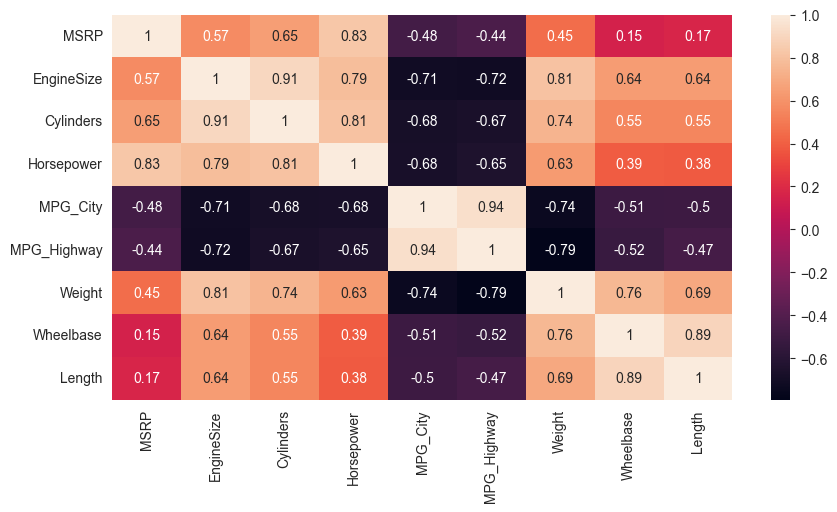

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(car_df.corr(numeric_only=True), annot=True)

kita akan memisahkan data kategorikal dengan encode

In [3]:
x_cat=car_df[['Make','Type','Origin','DriveTrain']]

In [4]:
y=car_df['MSRP']

In [5]:
car_df=car_df.drop(columns=['Model','Make','Type','Origin','DriveTrain','MSRP'])

In [6]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
x_cat=encoder.fit_transform(x_cat).toarray()

In [7]:
x_cat=pd.DataFrame(x_cat,index=car_df.index,columns=encoder.get_feature_names_out())

In [8]:
x=pd.concat([car_df,x_cat],axis=1)

In [55]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 58 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EngineSize          428 non-null    float64
 1   Cylinders           428 non-null    int64  
 2   Horsepower          428 non-null    int64  
 3   MPG_City            428 non-null    int64  
 4   MPG_Highway         428 non-null    int64  
 5   Weight              428 non-null    int64  
 6   Wheelbase           428 non-null    int64  
 7   Length              428 non-null    int64  
 8   Make_Acura          428 non-null    float64
 9   Make_Audi           428 non-null    float64
 10  Make_BMW            428 non-null    float64
 11  Make_Buick          428 non-null    float64
 12  Make_Cadillac       428 non-null    float64
 13  Make_Chevrolet      428 non-null    float64
 14  Make_Chrysler       428 non-null    float64
 15  Make_Dodge          428 non-null    float64
 16  Make_For

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [10]:
from sklearn.model_selection import GridSearchCV
param={
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[200,500,1000],
    'subsample':[0.2,0.5,0.8],
    'min_child_weight':[1,3],
    'gamma':[0,0.1]
}

In [11]:
from xgboost import XGBRegressor
model_xgb=GridSearchCV(
    estimator=XGBRegressor(random_state=42,objective='reg:squarederror'),
    param_grid=param,
    cv=5,
    verbose=3
)
model_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV 1/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.2;, score=0.868 total time=   0.1s
[CV 2/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.2;, score=0.633 total time=   0.1s
[CV 3/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.2;, score=0.721 total time=   0.1s
[CV 4/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.2;, score=0.524 total time=   0.0s
[CV 5/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.2;, score=0.834 total time=   0.0s
[CV 1/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.5;, score=0.890 total time=   0.1s
[CV 2/5] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, sub

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'gamma': [0, 0.1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [12]:
model_xgb.best_params_

{'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 1000,
 'subsample': 0.8}

In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=model_xgb.predict(x_test)
print("mse:",mean_squared_error(y_test,y_predict_xgb))
print("r2:",r2_score(y_test,y_predict_xgb))
print("mae:",mean_absolute_error(y_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_predict_xgb)))
r2_score_grid=r2_score(y_test,y_predict_xgb)
rmse_grid=np.sqrt(mean_squared_error(y_test,y_predict_xgb))

mse: 26322576.0
r2: 0.9220973253250122
mae: 3527.968505859375
rmse: 5130.553186548211


sekarang kita akan menggunakan random search

In [14]:
from sklearn.model_selection import RandomizedSearchCV
param={
    'max_depth':[2,3,5,6,7],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[200,500,1000],
    'subsample':[0.2,0.4,0.5,0.8,0.9],
    'min_child_weight':[3,4,5],
    'gamma':[0,0.1,0.3]
}

In [18]:
model_xgb2=RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42,objective='reg:squarederror'),
    param_distributions=param,
    cv=5,
    verbose=3,
    n_iter=100
)
model_xgb2.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END gamma=0.3, learning_rate=0.01, max_depth=2, min_child_weight=3, n_estimators=1000, subsample=0.8;, score=0.842 total time=   0.3s
[CV 2/5] END gamma=0.3, learning_rate=0.01, max_depth=2, min_child_weight=3, n_estimators=1000, subsample=0.8;, score=0.770 total time=   0.3s
[CV 3/5] END gamma=0.3, learning_rate=0.01, max_depth=2, min_child_weight=3, n_estimators=1000, subsample=0.8;, score=0.851 total time=   0.3s
[CV 4/5] END gamma=0.3, learning_rate=0.01, max_depth=2, min_child_weight=3, n_estimators=1000, subsample=0.8;, score=0.744 total time=   0.3s
[CV 5/5] END gamma=0.3, learning_rate=0.01, max_depth=2, min_child_weight=3, n_estimators=1000, subsample=0.8;, score=0.866 total time=   0.3s
[CV 1/5] END gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.9;, score=0.844 total time=   0.0s
[CV 2/5] END gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=3, n_e

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [3, 4, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [19]:
model_xgb2.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0}

In [27]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=model_xgb2.predict(x_test)
print("mse:",mean_squared_error(y_test,y_predict_xgb))
print("r2:",r2_score(y_test,y_predict_xgb))
print("mae:",mean_absolute_error(y_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_predict_xgb)))
r2_score_random=r2_score(y_test,y_predict_xgb)
rmse_random=np.sqrt(mean_squared_error(y_test,y_predict_xgb))

mse: 38825304.0
r2: 0.8850950598716736
mae: 3911.751220703125
rmse: 6230.995426093651


sekarang kita akan mengggunakan bayesian search

In [21]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
param={
    'learning_rate': Real(0.01, 0.5, prior='log-uniform'),
    'n_estimators': Integer(200, 3000),
    'max_depth': Integer(3, 8),
    'min_child_weight': Integer(1, 5),
    'subsample': Real(0.1, 0.9),
    'gamma': Real(0, 0.5)
}

In [22]:
model_xgb3=BayesSearchCV(
    estimator=XGBRegressor(random_state=42,objective='reg:squarederror'),
    n_iter=100,
    cv=5,
    verbose=3,
    search_spaces=param
)
model_xgb3.fit(x_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END gamma=0.013571576044116022, learning_rate=0.011485921615747898, max_depth=5, min_child_weight=2, n_estimators=2718, subsample=0.2964846512618;, score=0.878 total time=   1.3s
[CV 2/5] END gamma=0.013571576044116022, learning_rate=0.011485921615747898, max_depth=5, min_child_weight=2, n_estimators=2718, subsample=0.2964846512618;, score=0.792 total time=   1.4s
[CV 3/5] END gamma=0.013571576044116022, learning_rate=0.011485921615747898, max_depth=5, min_child_weight=2, n_estimators=2718, subsample=0.2964846512618;, score=0.892 total time=   1.3s
[CV 4/5] END gamma=0.013571576044116022, learning_rate=0.011485921615747898, max_depth=5, min_child_weight=2, n_estimators=2718, subsample=0.2964846512618;, score=0.769 total time=   1.3s
[CV 5/5] END gamma=0.013571576044116022, learning_rate=0.011485921615747898, max_depth=5, min_child_weight=2, n_estimators=2718, subsample=0.2964846512618;, score=0.843 total time=   1.3s
F

,estimator,"XGBRegressor(...ree=None, ...)"
,search_spaces,"{'gamma': Real(low=0, h...m='normalize'), 'learning_rate': Real(low=0.01...m='normalize'), 'max_depth': Integer(low=3...m='normalize'), 'min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,100
,scoring,None
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [23]:
model_xgb3.best_params_

OrderedDict([('gamma', 0.0),
             ('learning_rate', 0.1814486816623649),
             ('max_depth', 3),
             ('min_child_weight', 1),
             ('n_estimators', 3000),
             ('subsample', 0.9)])

In [26]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=model_xgb3.predict(x_test)
print("mse:",mean_squared_error(y_test,y_predict_xgb))
print("r2:",r2_score(y_test,y_predict_xgb))
print("mae:",mean_absolute_error(y_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_predict_xgb)))
r2_score_bayes=r2_score(y_test,y_predict_xgb)
rmse_bayes=np.sqrt(mean_squared_error(y_test,y_predict_xgb))

mse: 30071164.0
r2: 0.9110032320022583
mae: 3925.536865234375
rmse: 5483.7180817397975


disini kita akan membandingkan hasil dari r2 dan rmse dari masing2 metode

In [33]:
model_perbandingan=pd.DataFrame({
    "model":['Grid search','Random search','Bayes'],
    "R2_score":[r2_score_grid,(r2_score_random),r2_score_bayes],
    'RMSE_score':[rmse_grid,rmse_bayes,rmse_bayes]
}
)

jadi disini menggunakan sublot agar gambar bisa ditampilkan di satu frame

untuk score rmse yang paling kecil adalah juaranya

Text(0, 0.5, 'RMSE_score')

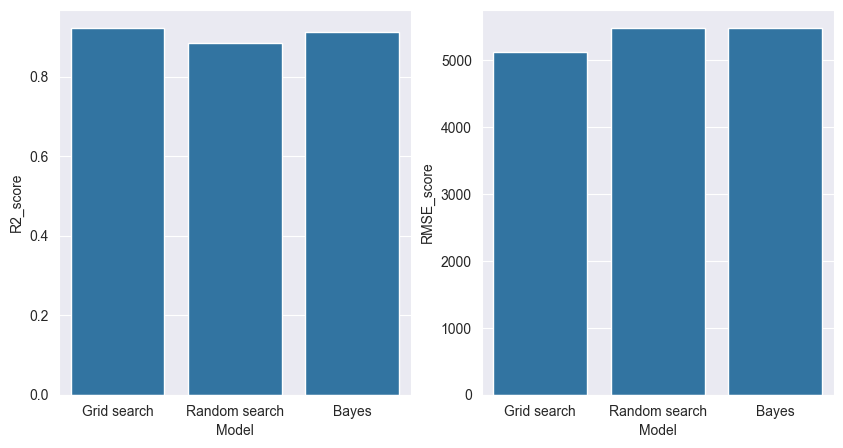

In [31]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(x="model",y="R2_score",data=model_perbandingan)
plt.xlabel('Model')
plt.ylabel('R2_score')
plt.subplot(1,2,2)
sns.barplot(x='model',y='RMSE_score',data=model_perbandingan)
plt.xlabel('Model')
plt.ylabel('RMSE_score')